Eksperimen 2 menggunakan pipeline preprocessing grayscale, lalu Gaussian Blur, lalu Contrast Stretching, kemudian ekstraksi fitur GLCM dan klasifikasi. Gaussian Blur menekan noise terlebih dahulu, lalu Contrast Stretching melebarkan rentang intensitas piksel agar perbedaan tekstur antara daging segar dan busuk lebih tegas saat diukur oleh GLCM. Pembagian data, jumlah derajat keabuan GLCM, dan konfigurasi model dibuat sama dengan eksperimen lain, yaitu split 80 banding 20 dengan random state 42, Random Forest dengan lima pohon, SVM kernel RBF, dan KNN dengan lima tetangga, agar perbandingan akurasi antar pipeline adil.

# Import Library

In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from IPython.display import display

Sel ini mengimpor seluruh pustaka yang dibutuhkan. Modul os dipakai untuk menelusuri folder dataset, OpenCV untuk membaca citra dan melakukan resize, numpy untuk operasi matriks termasuk preprocessing dari nol, serta matplotlib dan seaborn untuk visualisasi. Pandas dipakai untuk menyusun tabel fitur, skimage untuk menghitung GLCM, scipy untuk menghitung entropi, dan scikit-learn untuk pembagian data, pelatihan, serta evaluasi model.

# Data Loading

In [2]:
data = []
labels = []
file_name = []
for sub_folder in sorted(os.listdir("meat")):
    folder_path = os.path.join("meat", sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in sorted(os.listdir(folder_path)):
        img_path = os.path.join("meat", sub_folder, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = img.astype(np.uint8)
        img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

labels = np.array(labels)
print("Total citra dimuat:", len(data))

Total citra dimuat: 2000


Sel ini membaca seluruh citra dari folder meat yang berisi subfolder FreshMeat dan RottenMeat. Setiap citra dibaca dengan OpenCV lalu dikonversi menjadi grayscale, kemudian citra, label berupa nama subfolder, dan nama filenya disimpan ke dalam tiga list. Pemanggilan listdir diurutkan agar urutan data konsisten di mesin mana pun sehingga hasil pembagian data dapat direproduksi.


Sel ini menampilkan distribusi jumlah citra pada tiap label dalam bentuk grafik batang untuk memastikan data antar kelas seimbang sekaligus menentukan apakah augmentasi diperlukan.

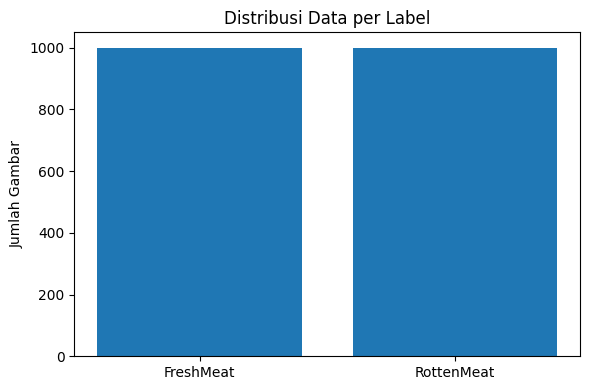

Jumlah total data: 2000
  FreshMeat: 1000 file
  RottenMeat: 1000 file


In [3]:
unique_labels, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar(unique_labels, counts)
plt.ylabel("Jumlah Gambar")
plt.title("Distribusi Data per Label")
plt.tight_layout()
plt.show()

print("Jumlah total data:", len(labels))
for lab, c in zip(unique_labels, counts):
    print(f"  {lab}: {c} file")


Sel ini menampilkan beberapa contoh citra dari masing masing label agar karakteristik visual data seperti pencahayaan, kondisi background, dan tingkat noise dapat dipahami sebelum menentukan teknik preprocessing.

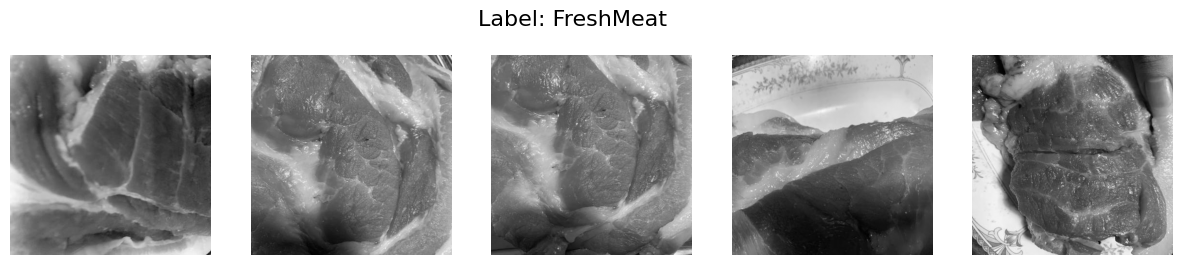

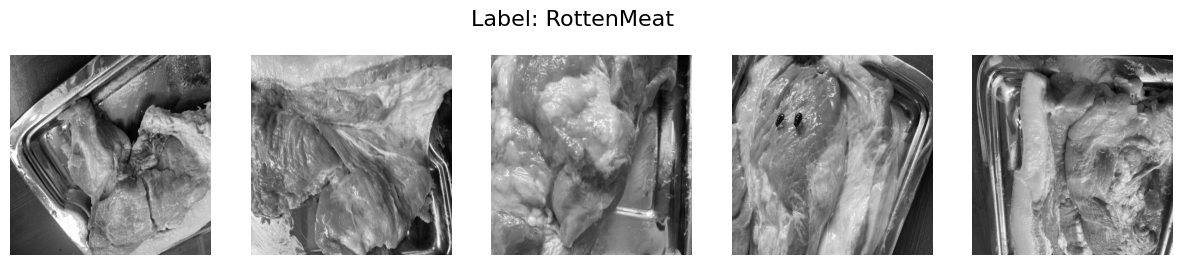

In [4]:
label_to_images = {lab: [] for lab in np.unique(labels)}
for img, lab in zip(data, labels):
    if len(label_to_images[lab]) < 5:
        label_to_images[lab].append(img)

for lab in label_to_images:
    fig, axs = plt.subplots(1, 5, figsize=(15, 3))
    fig.suptitle(f"Label: {lab}", fontsize=16)
    for i in range(5):
        axs[i].axis("off")
        if i < len(label_to_images[lab]):
            axs[i].imshow(label_to_images[lab][i], cmap="gray")
    plt.show()

# Data Preparation
## Data Augmentation

In [5]:
data_augmented = []
labels_augmented = []
for i in range(len(data)):
    pass  # augmentasi tidak diperlukan (data sudah lebih dari 100 per kelas dan seimbang)

print("Data sebelum augmentasi:", len(data))
print("Augmentasi dilewati, data tetap:", len(data))

Data sebelum augmentasi: 2000
Augmentasi dilewati, data tetap: 2000


Augmentasi data hanya diwajibkan bila jumlah citra berada di bawah rentang 70 hingga 100 per kelas. Dataset ini memiliki 1000 citra per kelas dan sudah seimbang, jauh di atas ambang tersebut, sehingga tahap augmentasi tidak diperlukan dan dilewati. Data yang dipakai pada tahap berikutnya tetap data hasil loading.

## Preprocessing

In [6]:
RESIZE_DIM   = (128, 128)
GAUSS_KSIZE  = 3
GAUSS_SIGMA  = 1.0
STRETCH_LOW  = 2
STRETCH_HIGH = 98


def resize(image, target_size=RESIZE_DIM):
    return cv.resize(image, target_size, interpolation=cv.INTER_AREA)


def gaussian_kernel(size, sigma=1.0):
    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-0.5 * (np.square(xx) + np.square(yy)) / np.square(sigma))
    return kernel / np.sum(kernel)


def gaussian_blur(img, k=GAUSS_KSIZE, sigma=GAUSS_SIGMA):
    kernel = gaussian_kernel(k, sigma)
    pad = k // 2
    padded = np.pad(img, pad, mode="reflect")
    windows = sliding_window_view(padded, (k, k))
    return np.sum(windows * kernel, axis=(2, 3)).astype(np.uint8)


def contrast_stretching(img, low=STRETCH_LOW, high=STRETCH_HIGH):
    i_min = np.percentile(img, low)
    i_max = np.percentile(img, high)
    if i_max <= i_min:
        return img.copy()
    out = (img.astype(np.float64) - i_min) * 255.0 / (i_max - i_min)
    return np.clip(out, 0, 255).astype(np.uint8)

Sel ini mendefinisikan tiga tahap preprocessing Eksperimen 2 yang dibangun dari nol, dengan OpenCV hanya dipakai untuk resize. Fungsi resize menyeragamkan ukuran citra menjadi 128 kali 128 piksel agar fitur GLCM sebanding antar citra. Fungsi gaussian blur mengonvolusikan citra dengan kernel Gaussian yang dibangun manual untuk meredam noise sebelum tekstur diukur. Fungsi contrast stretching memetakan ulang intensitas dari persentil ke dua hingga ke sembilan puluh delapan menjadi rentang penuh 0 hingga 255, dan pemakaian persentil membuat peregangan tahan terhadap piksel outlier yang sangat terang atau gelap.

## Penerapan Preprocessing

In [7]:
dataPreprocessed = []
for i in range(len(data)):
    img = data[i].astype(np.uint8)
    img = resize(img)
    img = gaussian_blur(img)
    img = contrast_stretching(img)
    dataPreprocessed.append(img)

print("Total citra siap diekstrak GLCM:", len(dataPreprocessed))

Total citra siap diekstrak GLCM: 2000


Sel ini menerapkan ketiga tahap preprocessing secara berurutan, yaitu resize lalu gaussian blur lalu contrast stretching, ke seluruh citra dan menyimpannya ke dalam dataPreprocessed yang siap diekstraksi GLCM.


Sel ini menampilkan setiap tahap preprocessing, yaitu grayscale ter-resize, hasil gaussian blur, dan hasil contrast stretching, untuk satu contoh citra dari tiap label agar efek tiap tahap terlihat jelas.

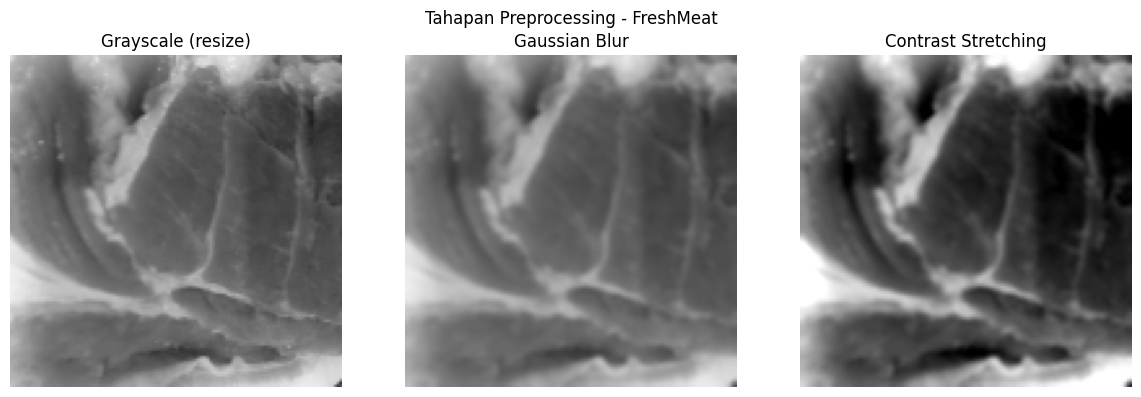

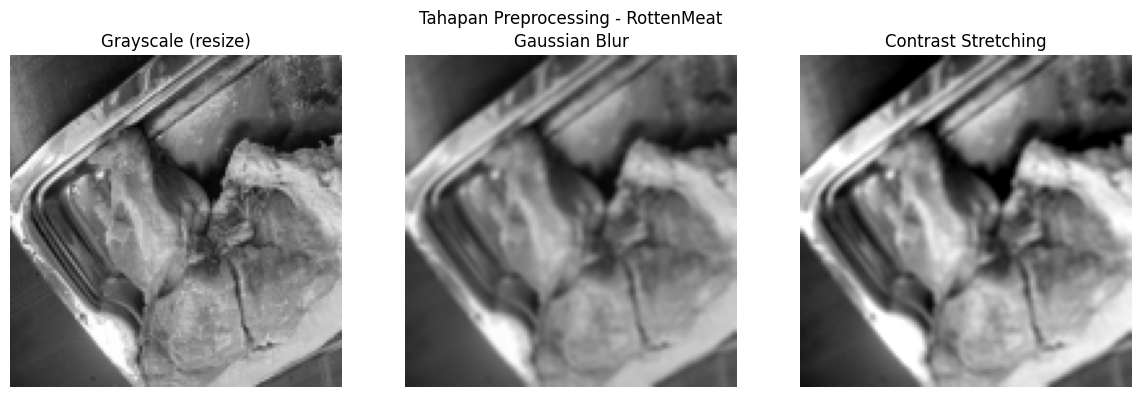

In [8]:
def show_stages(gray, judul=""):
    t1 = resize(gray.astype(np.uint8))
    t2 = gaussian_blur(t1)
    t3 = contrast_stretching(t2)
    nama = ["Grayscale (resize)", "Gaussian Blur", "Contrast Stretching"]
    citra = [t1, t2, t3]
    plt.figure(figsize=(12, 4))
    for i in range(3):
        plt.subplot(1, 3, i + 1)
        plt.imshow(citra[i], cmap="gray", vmin=0, vmax=255)
        plt.title(nama[i])
        plt.axis("off")
    plt.suptitle(judul)
    plt.tight_layout()
    plt.show()


seen = {}
for i, lab in enumerate(labels):
    if lab not in seen:
        seen[lab] = i
for lab, idx in seen.items():
    show_stages(data[idx], judul=f"Tahapan Preprocessing - {lab}")

# Feature Extraction

In [9]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Sudut harus salah satu dari: 0, 45, 90, 135.")
    return graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)


def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

Sel ini mendefinisikan fungsi glcm yang menghitung Gray Level Co occurrence Matrix pada sudut 0, 45, 90, dan 135 derajat dengan jarak satu piksel, simetris, ternormalisasi, dan 256 derajat keabuan. Tujuh fungsi lainnya mengekstrak properti tekstur dari matriks tersebut, yaitu correlation, dissimilarity, homogeneity, contrast, ASM, energy, dan entropy.

## Fungsi Evaluasi Cepat dan Perbandingan Antar Eksperimen

In [10]:
comparison_results = []


def extract_and_evaluate(processed_data, labels_data, experiment_name):
    features = []
    for img in processed_data:
        feat_row = []
        for angle in [0, 45, 90, 135]:
            g = glcm(img, angle)
            feat_row.extend([
                contrast(g), correlation(g), energy(g),
                homogenity(g), ASM(g), entropyGlcm(g), dissimilarity(g)
            ])
        features.append(feat_row)

    cols = []
    for angle in [0, 45, 90, 135]:
        cols.extend([
            f'Contrast{angle}', f'Correlation{angle}', f'Energy{angle}',
            f'Homogeneity{angle}', f'ASM{angle}', f'Entropy{angle}', f'Dissimilarity{angle}'
        ])
    df_features = pd.DataFrame(features, columns=cols)

    X_train, X_test, y_train, y_test = train_test_split(
        df_features, labels_data, test_size=0.2, random_state=42
    )
    X_train_mean, X_train_std = X_train.mean(), X_train.std()
    X_train = (X_train - X_train_mean) / X_train_std
    X_test = (X_test - X_train_mean) / X_train_std

    models = {
        'KNN': KNeighborsClassifier(n_neighbors=5),
        'SVM': SVC(kernel='rbf', random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=5, random_state=42)
    }
    accuracies = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        accuracies[name] = accuracy_score(y_test, model.predict(X_test))
    return accuracies


def prepro2():
    print("Menjalankan Eksperimen 2 (Gaussian Blur + Contrast Stretching)...")
    acc = extract_and_evaluate(dataPreprocessed, labels, "Prepro 2")
    comparison_results.append(("Eksperimen 2", acc))
    for name, a in acc.items():
        print(f"  {name}: {a:.4f}")
    return acc

_ = prepro2()

Menjalankan Eksperimen 2 (Gaussian Blur + Contrast Stretching)...
  KNN: 0.9400
  SVM: 0.9450
  Random Forest: 0.9225


Fungsi extract and evaluate melakukan ekstraksi GLCM, pembagian data 80 banding 20, normalisasi, lalu melatih ketiga model dan mengembalikan akurasinya, sementara comparison results menampung hasil tiap eksperimen agar mudah dibandingkan di akhir proyek. Fungsi ini memakai seluruh 28 fitur tanpa seleksi fitur sebagai pembanding cepat, sehingga akurasinya dapat sedikit berbeda dari pipeline utama di bawah yang memakai fitur hasil seleksi.

## Ekstraksi Fitur GLCM pada Berbagai Derajat

In [11]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)

    correlation0.append(correlation(D0)); correlation45.append(correlation(D45))
    correlation90.append(correlation(D90)); correlation135.append(correlation(D135))

    Kontras0.append(contrast(D0)); Kontras45.append(contrast(D45))
    Kontras90.append(contrast(D90)); Kontras135.append(contrast(D135))

    dissimilarity0.append(dissimilarity(D0)); dissimilarity45.append(dissimilarity(D45))
    dissimilarity90.append(dissimilarity(D90)); dissimilarity135.append(dissimilarity(D135))

    homogenity0.append(homogenity(D0)); homogenity45.append(homogenity(D45))
    homogenity90.append(homogenity(D90)); homogenity135.append(homogenity(D135))

    entropy0.append(entropyGlcm(D0)); entropy45.append(entropyGlcm(D45))
    entropy90.append(entropyGlcm(D90)); entropy135.append(entropyGlcm(D135))

    ASM0.append(ASM(D0)); ASM45.append(ASM(D45))
    ASM90.append(ASM(D90)); ASM135.append(ASM(D135))

    energy0.append(energy(D0)); energy45.append(energy(D45))
    energy90.append(energy(D90)); energy135.append(energy(D135))

Sel ini menyiapkan list penampung untuk ketujuh fitur tekstur pada keempat sudut. Untuk setiap citra, matriks GLCM dihitung per sudut lalu seluruh fiturnya langsung diambil, dan matriks tidak disimpan agar penggunaan memori tetap ringan meskipun jumlah citra besar.

## Penyimpanan Hasil Ekstraksi ke CSV

In [12]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_2.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_2.csv')
display(hasilEkstrak.head())

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,0001.jpg,FreshMeat,83.280696,186.610515,109.169722,183.852936,0.230766,0.188024,0.250352,0.172252,...,0.001525,0.001080,0.037265,0.033971,0.039046,0.032860,0.988979,0.974950,0.985485,0.975318
1,0002.jpg,FreshMeat,87.321358,121.169198,77.867864,187.426375,0.229635,0.196673,0.227907,0.169577,...,0.001319,0.000979,0.036278,0.033657,0.036323,0.031287,0.986201,0.980708,0.987634,0.970160
2,0003.jpg,FreshMeat,83.404158,162.291835,94.558501,173.779094,0.231584,0.176600,0.211737,0.167621,...,0.001287,0.001028,0.037290,0.032908,0.035875,0.032059,0.988600,0.977678,0.987030,0.976100
3,0004.jpg,FreshMeat,25.565145,128.911464,80.887180,75.629177,0.380081,0.246898,0.297860,0.273880,...,0.001492,0.001332,0.042201,0.036810,0.038628,0.036493,0.998081,0.990296,0.993896,0.994306
4,0005.jpg,FreshMeat,140.177473,178.625519,107.796506,292.735383,0.202923,0.175319,0.230974,0.158668,...,0.001076,0.000778,0.031776,0.030550,0.032810,0.027890,0.983849,0.979331,0.987639,0.966129


Sel ini menggabungkan seluruh fitur beserta nama file dan label ke dalam sebuah DataFrame, menyimpannya ke berkas hasil ekstraksi 2 berformat csv, lalu membacanya kembali untuk memastikan datanya tersimpan dengan benar.


Sel ini melakukan seleksi fitur berbasis korelasi. Bila dua fitur memiliki korelasi lebih besar atau sama dengan 0,95 maka salah satunya dibuang agar tidak redundan, kemudian korelasi antar fitur terpilih ditampilkan dalam bentuk heatmap.

Jumlah fitur sebelum seleksi : 28
Jumlah fitur setelah seleksi : 20
Fitur terpilih: ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Homogeneity135', 'Entropy0', 'Entropy45', 'Entropy90', 'Entropy135', 'ASM0', 'ASM45', 'ASM90', 'ASM135', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


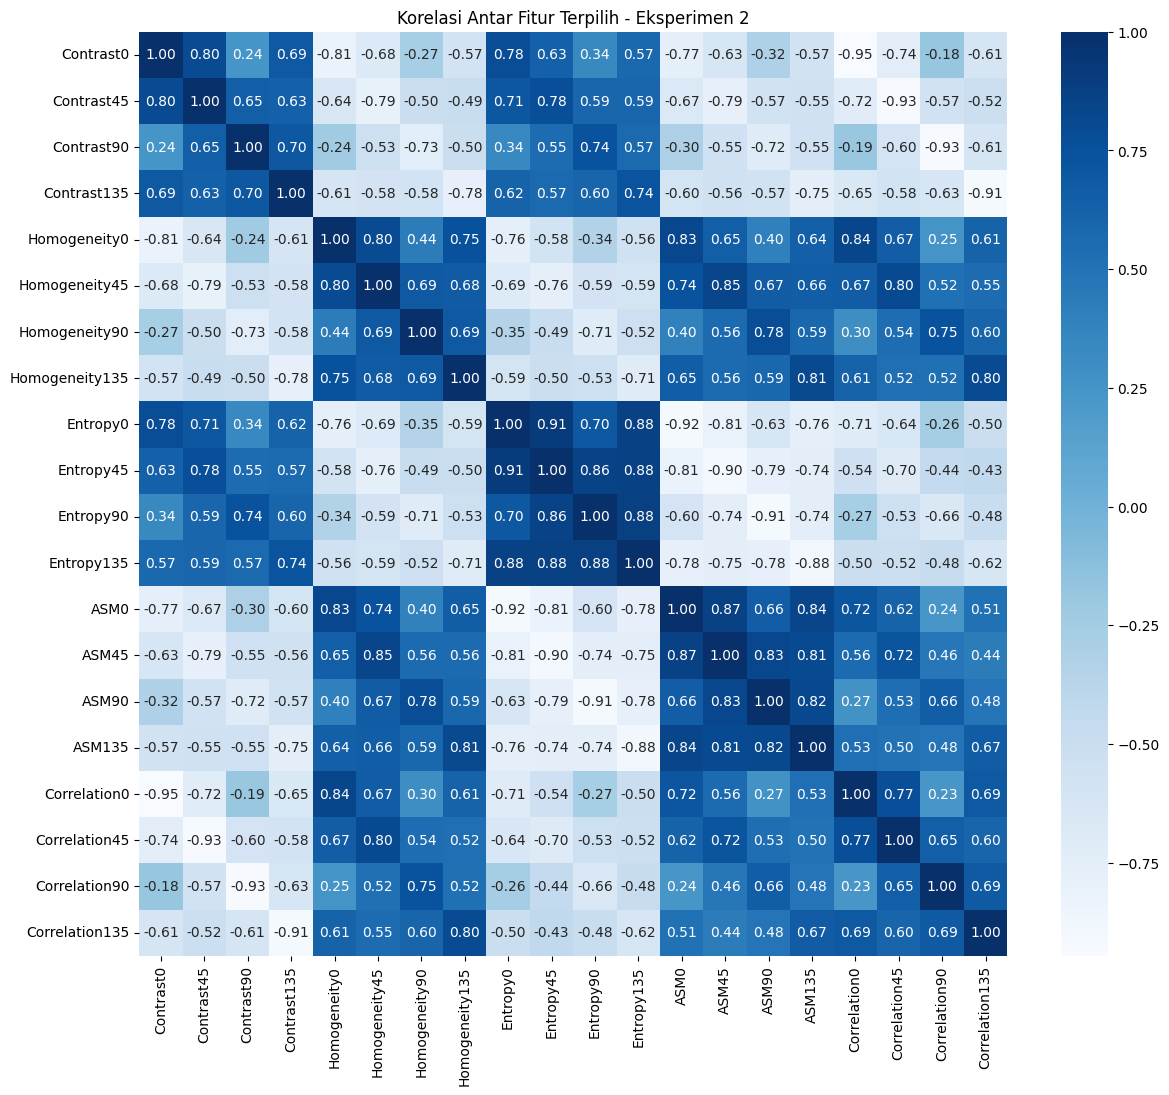

In [13]:
corr = hasilEkstrak.drop(columns=['Label', 'Filename']).corr()
threshold = 0.95
columns = np.full((corr.shape[0],), True, dtype=bool)
for i in range(corr.shape[0]):
    for j in range(i + 1, corr.shape[0]):
        if corr.iloc[i, j] >= threshold and columns[i]:
            columns[j] = False

select = hasilEkstrak.drop(columns=['Label', 'Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']
print("Jumlah fitur sebelum seleksi :", hasilEkstrak.shape[1] - 2)
print("Jumlah fitur setelah seleksi :", x_new.shape[1])
print("Fitur terpilih:", list(select))

plt.figure(figsize=(14, 12))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Korelasi Antar Fitur Terpilih - Eksperimen 2')
plt.show()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

X_train: (1600, 20)
X_test : (400, 20)


Sel ini membagi data menjadi 80 persen data latih dan 20 persen data uji dengan random state 42 agar konsisten dengan eksperimen lain, lalu melakukan standardisasi z score menggunakan rata rata dan standar deviasi yang dihitung dari data latih.

# Modeling

In [ ]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

rf = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

Sel ini mendefinisikan fungsi pencetak laporan evaluasi serta ketiga model klasifikasi dengan konfigurasi yang sama seperti eksperimen lain, yaitu Random Forest dengan lima pohon, SVM kernel RBF, dan KNN dengan lima tetangga.

## Training dan Evaluasi Random Forest

In [ ]:
rf.fit(X_train, y_train)
print("------Training Set Random Forest------")
generateClassificationReport(y_train, rf.predict(X_train))
print("\n------Testing Set Random Forest------")
generateClassificationReport(y_test, rf.predict(X_test))

------Training Set Random Forest------
              precision    recall  f1-score   support

   FreshMeat       1.00      0.99      0.99       801
  RottenMeat       0.99      1.00      0.99       799

    accuracy                           0.99      1600
   macro avg       0.99      0.99      0.99      1600
weighted avg       0.99      0.99      0.99      1600

[[792   9]
 [  3 796]]
Accuracy: 0.9925

------Testing Set Random Forest------
              precision    recall  f1-score   support

   FreshMeat       0.95      0.90      0.92       199
  RottenMeat       0.91      0.95      0.93       201

    accuracy                           0.93       400
   macro avg       0.93      0.92      0.92       400
weighted avg       0.93      0.93      0.92       400

[[179  20]
 [ 10 191]]
Accuracy: 0.925


Random Forest mencapai akurasi latih 99,25 persen namun turun menjadi 92,50 persen pada data uji, sehingga terdapat selisih sekitar 6,75 poin yang mengindikasikan adanya overfitting ringan, yaitu model menghafal pola data latih lebih kuat daripada kemampuannya menggeneralisasi. Meski demikian, akurasi uji 92,50 persen tetap tergolong tinggi untuk pembedaan daging segar dan busuk berbasis tekstur GLCM. Pada confusion matrix data uji, dari 199 citra FreshMeat sebanyak 179 dikenali benar dan 20 keliru ditebak sebagai RottenMeat, sedangkan dari 201 citra RottenMeat sebanyak 191 benar dan hanya 10 yang keliru. Pola ini menunjukkan model sedikit lebih sulit mengenali daging segar dengan recall sekitar 0,90 dibanding daging busuk dengan recall sekitar 0,95, kemungkinan karena peregangan kontras membuat sebagian tekstur permukaan daging segar menyerupai daging busuk.

## Training dan Evaluasi SVM

In [ ]:
svm.fit(X_train, y_train)
print("------Training Set SVM------")
generateClassificationReport(y_train, svm.predict(X_train))
print("\n------Testing Set SVM------")
generateClassificationReport(y_test, svm.predict(X_test))

------Training Set SVM------
              precision    recall  f1-score   support

   FreshMeat       0.96      0.94      0.95       801
  RottenMeat       0.94      0.96      0.95       799

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600

[[749  52]
 [ 33 766]]
Accuracy: 0.946875

------Testing Set SVM------
              precision    recall  f1-score   support

   FreshMeat       0.96      0.90      0.93       199
  RottenMeat       0.91      0.97      0.93       201

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.93       400

[[179  20]
 [  7 194]]
Accuracy: 0.9325


SVM dengan kernel RBF menghasilkan performa paling stabil sekaligus tertinggi pada data uji, yaitu 93,25 persen, dengan akurasi latih 94,69 persen sehingga selisih latih dan uji hanya sekitar 1,4 poin. Selisih yang kecil ini menandakan batas keputusan yang dibentuk SVM menggeneralisasi dengan baik dan tidak overfitting seperti Random Forest. Pada confusion matrix data uji, 179 dari 199 FreshMeat dikenali benar dengan 20 keliru, dan 194 dari 201 RottenMeat benar dengan hanya 7 keliru, sehingga recall RottenMeat menjadi yang tertinggi di antara ketiga model yaitu sekitar 0,965. Kestabilan ini wajar karena fitur GLCM hasil contrast stretching tersebar pada rentang nilai yang lebar, dan SVM memproyeksikannya ke ruang berdimensi lebih tinggi sehingga kedua kelas dapat dipisahkan dengan margin yang optimal.

## Training dan Evaluasi KNN

In [ ]:
knn.fit(X_train, y_train)
print("------Training Set KNN------")
generateClassificationReport(y_train, knn.predict(X_train))
print("\n------Testing Set KNN------")
generateClassificationReport(y_test, knn.predict(X_test))

------Training Set KNN------
              precision    recall  f1-score   support

   FreshMeat       0.98      0.97      0.97       801
  RottenMeat       0.97      0.98      0.97       799

    accuracy                           0.97      1600
   macro avg       0.97      0.97      0.97      1600
weighted avg       0.97      0.97      0.97      1600

[[774  27]
 [ 16 783]]
Accuracy: 0.973125

------Testing Set KNN------
              precision    recall  f1-score   support

   FreshMeat       0.94      0.91      0.92       199
  RottenMeat       0.91      0.94      0.93       201

    accuracy                           0.93       400
   macro avg       0.93      0.92      0.92       400
weighted avg       0.93      0.93      0.92       400

[[181  18]
 [ 12 189]]
Accuracy: 0.925


KNN dengan jumlah tetangga lima memperoleh akurasi latih 97,31 persen dan akurasi uji 92,50 persen, dengan selisih sekitar 4,8 poin yang lebih besar dari SVM namun lebih kecil dari Random Forest. Pada confusion matrix data uji, 181 dari 199 FreshMeat benar dengan 18 keliru, dan 189 dari 201 RottenMeat benar dengan 12 keliru, menghasilkan performa yang seimbang antara kedua kelas dengan f1 score sekitar 0,92 hingga 0,93. Karena KNN mengandalkan kedekatan jarak antar vektor fitur, normalisasi z score menjadi krusial agar fitur dengan rentang besar seperti contrast tidak mendominasi perhitungan jarak. Hasil yang baik ini menunjukkan bahwa pada ruang fitur hasil Eksperimen 2, citra dari kelas yang sama memang cenderung berkelompok secara konsisten.

# Evaluation
Sel ini menampilkan confusion matrix tiap model untuk melihat pola kesalahan klasifikasi antara daging segar dan daging busuk.

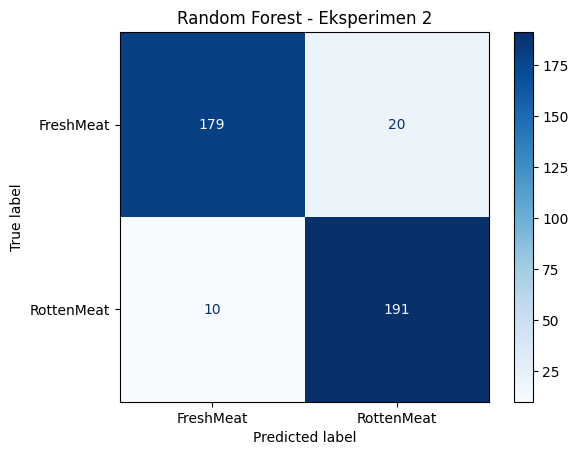

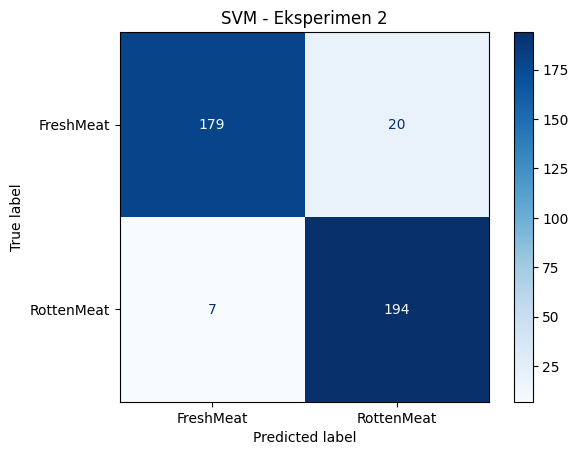

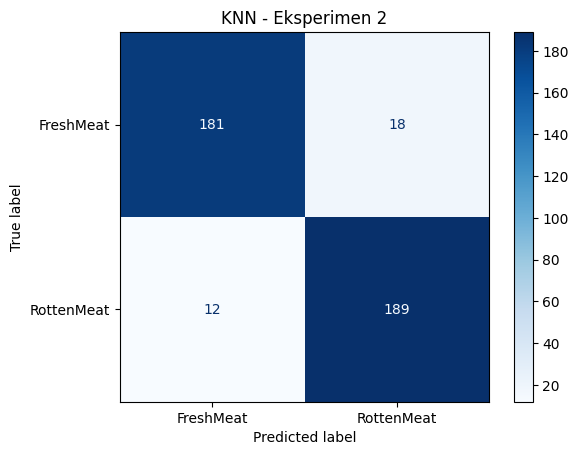

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, rf.predict(X_test), "Random Forest - Eksperimen 2")
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM - Eksperimen 2")
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN - Eksperimen 2")

## Kesimpulan Eksperimen 2

Pipeline Eksperimen 2 yang terdiri dari grayscale, Gaussian Blur, lalu Contrast Stretching menghasilkan fitur GLCM yang konsisten memisahkan daging segar dan busuk pada ketiga model, dengan akurasi uji berkisar 92,50 persen hingga 93,25 persen. SVM kernel RBF menjadi model terbaik dengan 93,25 persen sekaligus paling stabil, diikuti Random Forest dan KNN yang sama sama 92,50 persen. Gaussian Blur berperan meredam noise sehingga tekstur yang diukur GLCM lebih mewakili kondisi permukaan daging, sementara Contrast Stretching melebarkan rentang intensitas sehingga perbedaan antar kelas menjadi lebih tegas. Rapatnya akurasi ketiga model menunjukkan fitur yang dihasilkan cukup kuat dan tidak terlalu bergantung pada pemilihan algoritma klasifikasi.